# CIFAR-10 AVG v2 — Custom Residual CNN + SVM Training

Use the official CIFAR-10 development split only. This notebook preserves the existing AVG grayscale preprocessing, fits a custom residual CNN and an individual SVM, and selects checkpoints and parameters using validation data. Official test scoring remains in `AVG Testing.ipynb`.


In [1]:
import os
import gc
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

SEED = 30092026
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass
tf.random.set_seed(SEED)
tf.keras.mixed_precision.set_global_policy("mixed_float16")

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, Add, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

print("GPU:", tf.config.list_physical_devices("GPU"))
print("Mixed precision:", tf.keras.mixed_precision.global_policy())

I0000 00:00:1791279099.610187  126191 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791279099.649813  126191 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791279100.627965  126191 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision: <DTypePolicy "mixed_float16">


## 1. Load CIFAR-10

CIFAR-10 berisi 60.000 gambar RGB berukuran 32×32 pada 10 kelas.

Notebook training hanya mengambil **50.000 official training images**.
Official test split tidak digunakan di notebook ini.

Pada preprocessing, setiap gambar akan dikonversi menjadi **Grayscale AVG**:

```text
AVG = (R + G + B) / 3
```

In [2]:
# Di notebook training ini kita hanya mengambil official_train.
# Official test split dibuang dengan `_` dan tidak dipakai sama sekali.
(X_train_full, y_train_full), _ = cifar10.load_data()

labels = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

classes_name = [
    "Airplane", "Automobile", "Bird", "Cat", "Deer",
    "Dog", "Frog", "Horse", "Ship", "Truck"
]

print("Official CIFAR-10 RGB training images:", X_train_full.shape)
print("Official CIFAR-10 training labels    :", y_train_full.shape)

Official CIFAR-10 RGB training images: (50000, 32, 32, 3)
Official CIFAR-10 training labels    : (50000, 1)


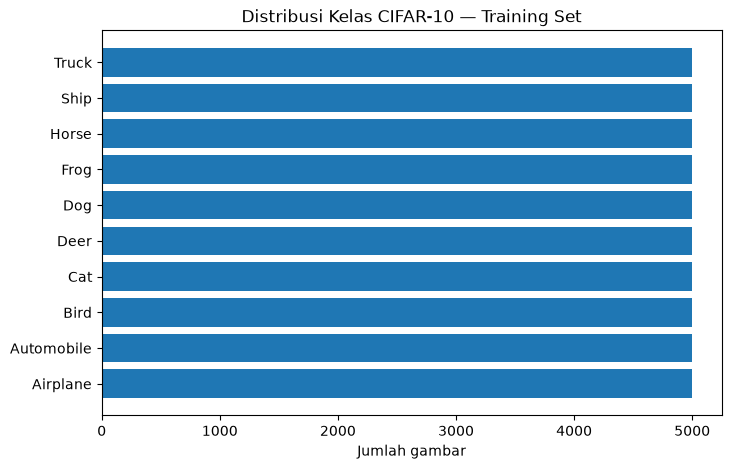

In [3]:
classes, counts = np.unique(y_train_full, return_counts=True)

plt.figure(figsize=(8, 5))
plt.barh(classes_name, counts)
plt.title("Distribusi Kelas CIFAR-10 — Training Set")
plt.xlabel("Jumlah gambar")
plt.show()

## 2. Tampilkan Contoh Gambar Grayscale AVG

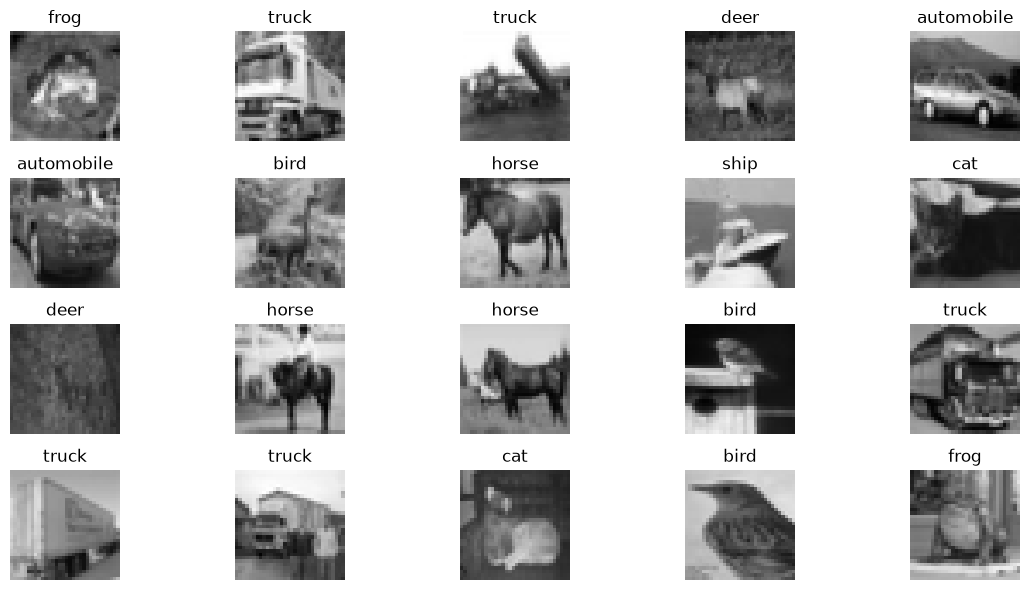

In [4]:
plt.figure(figsize=(12, 6))

for i in range(20):
    plt.subplot(4, 5, i + 1)

    avg_image = np.mean(
        X_train_full[i].astype("float32"),
        axis=-1
    )

    plt.imshow(
        avg_image,
        cmap="gray",
        vmin=0,
        vmax=255
    )
    plt.title(labels[int(y_train_full[i, 0])])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 3. Preprocessing Grayscale AVG dan Train/Validation Split

Konversi yang digunakan:

```text
AVG = (R + G + B) / 3
```

Setelah konversi, setiap image memiliki shape:

```text
32 × 32 × 1
```

Kemudian nilai pixel dinormalisasi ke rentang `[0, 1]`.

`SEED = 30092026` dan stratified split dipertahankan agar sample order konsisten dengan eksperimen RGB.

In [5]:
# RGB -> Grayscale AVG -> normalisasi.
X_train_full = np.mean(
    X_train_full.astype("float32"),
    axis=-1,
    keepdims=True
) / 255.0

y_train_full = y_train_full.flatten()

# Validation diambil dari official training split.
# X_val/y_val TIDAK digunakan untuk gradient update.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_full
)

y_cat_train = to_categorical(y_train, 10)
y_cat_val = to_categorical(y_val, 10)

print("Training data   :", X_train.shape, y_train.shape)
print("Validation data :", X_val.shape, y_val.shape)
print()
print("Data yang benar-benar digunakan model.fit() untuk update bobot:")
print("X_train =", X_train.shape)
print("y_train =", y_train.shape)

assert X_train.shape == (40000, 32, 32, 1)
assert X_val.shape == (10000, 32, 32, 1)

Training data   : (40000, 32, 32, 1) (40000,)
Validation data : (10000, 32, 32, 1) (10000,)

Data yang benar-benar digunakan model.fit() untuk update bobot:
X_train = (40000, 32, 32, 1)
y_train = (40000,)


## 4. Custom residual CNN

Four residual stages (64, 128, 256, 512 channels) preserve spatial information before global average pooling. The 512-dimensional `svm_features` layer is **signed**: its output is batch-normalized without ReLU, avoiding dead embedding channels. All weights are trained from scratch.

In [6]:
INPUT_SHAPE = (32, 32, 1)
BATCH_SIZE = 64  # On 6 GB VRAM, restart from the top with 32 if this runs out of memory.
MAX_EPOCHS = 100
INITIAL_LR = 1e-3
WEIGHT_DECAY = 1e-4


def residual_block(x, filters, stride, name):
    shortcut = x
    x = Conv2D(filters, 3, strides=stride, padding="same", use_bias=False, name=f"{name}_conv1")(x)
    x = BatchNormalization(name=f"{name}_bn1")(x)
    x = Activation("relu", name=f"{name}_relu1")(x)
    x = Conv2D(filters, 3, padding="same", use_bias=False, name=f"{name}_conv2")(x)
    x = BatchNormalization(name=f"{name}_bn2")(x)
    if stride != 1 or int(shortcut.shape[-1]) != filters:
        shortcut = Conv2D(filters, 1, strides=stride, padding="same", use_bias=False, name=f"{name}_shortcut_conv")(shortcut)
        shortcut = BatchNormalization(name=f"{name}_shortcut_bn")(shortcut)
    x = Add(name=f"{name}_add")([x, shortcut])
    return Activation("relu", name=f"{name}_out")(x)


def build_custom_cnn():
    inputs = Input(shape=INPUT_SHAPE, name="input_image")
    x = Conv2D(64, 3, padding="same", use_bias=False, name="stem_conv")(inputs)
    x = BatchNormalization(name="stem_bn")(x)
    x = Activation("relu", name="stem_relu")(x)
    for stage, filters in enumerate((64, 128, 256, 512), start=1):
        x = residual_block(x, filters, 1 if stage == 1 else 2, f"stage{stage}_block1")
        x = residual_block(x, filters, 1, f"stage{stage}_block2")
    feature_map = Activation("linear", name="feature_map")(x)
    pooled = GlobalAveragePooling2D(name="global_pool")(feature_map)
    projection = Dense(512, use_bias=False, name="embedding_dense")(pooled)
    embedding = BatchNormalization(name="svm_features", dtype="float32")(projection)
    head = Dropout(0.30, seed=SEED, name="classifier_dropout")(embedding)
    outputs = Dense(10, activation="softmax", dtype="float32", name="cnn_softmax")(head)
    model = Model(inputs, outputs, name="custom_cifar10_avg_residual_v2")
    steps = int(np.ceil(len(X_train) / BATCH_SIZE)) * MAX_EPOCHS
    schedule = tf.keras.optimizers.schedules.CosineDecay(INITIAL_LR, decay_steps=steps, alpha=0.01)
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=schedule, weight_decay=WEIGHT_DECAY),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=["accuracy"],
    )
    return model

In [7]:
# The final model is constructed once in the training section.
print("Architecture: CIFAR residual CNN with a signed 512-D embedding")

Architecture: CIFAR residual CNN with a signed 512-D embedding


## 5. Training augmentation

Augmentation is applied only to training images. Validation and test images use normalized pixels without random transforms.

In [8]:
data_generator = ImageDataGenerator(
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.10,
    fill_mode="reflect",
)

## 6. Fixed configuration

The previous eight-model CNN grid was expensive on a 6 GB GPU. This v2 run uses the fixed residual configuration above, at most 100 epochs, and validation-based checkpoint selection. No official test image or label is used here.

In [9]:
print("Training rows:", len(X_train))
print("Validation rows:", len(X_val))
print("Batch size:", BATCH_SIZE)
print("Maximum epochs:", MAX_EPOCHS)

Training rows: 40000
Validation rows: 10000
Batch size: 64
Maximum epochs: 100


In [10]:
# No preliminary CNN grid search: the compute budget is reserved for one full residual-CNN run.
print("Ready for AVG v2 training")

Ready for AVG v2 training


## 7. Train AVG CNN and save the best validation checkpoint

In [ ]:
CNN_MODEL_PATH = "cifar10_avg_cnn_v2.keras"
tf.keras.backend.clear_session()
gc.collect()
tf.random.set_seed(SEED)
model = build_custom_cnn()
model.summary()
train_generator = data_generator.flow(X_train, y_cat_train, batch_size=BATCH_SIZE, shuffle=True, seed=SEED)
callbacks = [
    ModelCheckpoint(CNN_MODEL_PATH, monitor="val_accuracy", mode="max", save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_accuracy", mode="max", patience=15, restore_best_weights=True, verbose=1),
]
history = model.fit(
    train_generator,
    epochs=MAX_EPOCHS,
    validation_data=(X_val, y_cat_val),
    callbacks=callbacks,
    verbose=1,
)

I0000 00:00:1791279103.802534  126191 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3385 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "custom_cifar10_avg_residual_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 32, 32, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 32, 32,    │        576 │ input_image[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 32, 32,    │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu           │ (None, 32, 32,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv1 │ (None, 32, 32,    │     36,864 │ stem_relu[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn1   │ (None, 32, 32,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu1 │ (None, 32, 32,    │          0 │ stage1_block1_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv2 │ (None, 32, 32,    │     36,864 │ stage1_block1_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn2   │ (None, 32, 32,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_add   │ (None, 32, 32,    │          0 │ stage1_block1_bn… │
│ (Add)               │ 64)               │            │ stem_relu[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_out   │ (None, 32, 32,    │          0 │ stage1_block1_ad… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_conv1 │ (None, 32, 32,    │     36,864 │ stage1_block1_ou… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_bn1   │ (None, 32, 32,    │        256 │ stage1_block2_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_relu1 │ (None, 32, 32,    │          0 │ stage1_block2_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_conv2 │ (None, 32, 32,    │     36,864 │ stage1_block2_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_bn2   │ (None, 32, 32,    │        256 │ stage1_block2_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_add   │ (None, 32, 32,    │          0 │ stage1_block2_bn

 Total params: 11,446,602 (43.67 MB)

 Trainable params: 11,435,978 (43.62 MB)

...

Epoch 1/100


I0000 00:00:1791279104.641165  126191 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1791279110.754487  126285 service.cc:153] XLA service 0x7235d403b8d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1791279110.754503  126285 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
I0000 00:00:1791279110.951496  126285 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1791279112.241462  126285 cuda_dnn.cc:461] Loaded cuDNN version 92600
I0000 00:00:1791279112.421668  126285 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16608__.144
I0000 00:00:1791279117.847752  126380 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusio

  3/625 ━━━━━━━━━━━━━━━━━━━━ 37s 60ms/step - accuracy: 0.1510 - loss: 3.8422

I0000 00:00:1791279125.375069  126285 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.3772 - loss: 1.9431
Epoch 1: val_accuracy improved from None to 0.31180, saving model to cifar10_avg_cnn_v2.keras

Epoch 1: finished saving model to cifar10_avg_cnn_v2.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 75ms/step - accuracy: 0.3772 - loss: 1.9431 - val_accuracy: 0.3118 - val_loss: 2.6366
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5388 - loss: 1.4973
Epoch 2: val_accuracy improved from 0.31180 to 0.46220, saving model to cifar10_avg_cnn_v2.keras

Epoch 2: finished saving model to cifar10_avg_cnn_v2.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 63ms/step - accuracy: 0.5388 - loss: 1.4973 - val_accuracy: 0.4622 - val_loss: 1.9075
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.6341 - loss: 1.2270
Epoch 3: val_accuracy improved from 0.46220 to 0.64740, saving model to cifar10_avg_cnn_v2.keras

Epoch 3: finished saving model to cifar10_avg_cnn_v2.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 63ms/step

## 8. Training Curve

In [ ]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["accuracy"], label="train_accuracy")
plt.plot(history_df["val_accuracy"], label="val_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

best_epoch = int(history_df["val_accuracy"].idxmax() + 1)
best_val_history = float(history_df["val_accuracy"].max())

print("Best epoch:", best_epoch)
print(
    f"Best validation accuracy during training: "
    f"{best_val_history * 100:.2f}%"
)

## 9. Load CNN Grayscale AVG Terbaik

Seluruh proses feature extraction berikutnya menggunakan checkpoint CNN AVG dengan validation accuracy terbaik.

In [ ]:
best_cnn = load_model(
    CNN_MODEL_PATH
)

cnn_val_loss, cnn_val_accuracy = best_cnn.evaluate(
    X_val,
    y_cat_val,
    verbose=1
)

print(f"CNN validation loss    : {cnn_val_loss:.4f}")
print(
    f"CNN validation accuracy: "
    f"{cnn_val_accuracy * 100:.2f}%"
)

## 10. Visualize selected CNN feature maps on a validation image

In [ ]:
FEATURE_MAP_LAYERS = ["stem_relu", "stage2_block2_out", "stage3_block2_out", "feature_map"]
feature_map_model = Model(best_cnn.input, [best_cnn.get_layer(name).output for name in FEATURE_MAP_LAYERS])
sample_index = 0
sample_image = X_val[sample_index:sample_index + 1]
feature_maps = feature_map_model.predict(sample_image, verbose=0)
plt.figure(figsize=(3, 3))
plt.imshow(sample_image[0, :, :, 0], cmap="gray")
plt.title(f"Input: {labels[y_val[sample_index]]}")
plt.axis("off")
plt.show()
for layer_name, fmap in zip(FEATURE_MAP_LAYERS, feature_maps):
    n_show = min(12, fmap.shape[-1])
    print(f"{layer_name}: {fmap.shape}")
    plt.figure(figsize=(12, 4))
    for i in range(n_show):
        plt.subplot(3, 4, i + 1)
        plt.imshow(fmap[0, :, :, i], cmap="viridis")
        plt.axis("off")
    plt.suptitle(layer_name)
    plt.tight_layout()
    plt.show()

## 11. Extract signed AVG embeddings for the individual SVM

Use the named `svm_features` layer (512 values) from the best validation checkpoint. These features are also extracted for all splits by `AVG Extraction.ipynb`.

In [ ]:
feature_extractor = Model(
    inputs=best_cnn.input,
    outputs=best_cnn.get_layer(
        "svm_features"
    ).output,
    name="cnn_feature_extractor"
)

feature_extractor.summary()

In [ ]:
X_train_features = feature_extractor.predict(X_train, batch_size=128, verbose=1).astype(np.float32)
X_val_features = feature_extractor.predict(X_val, batch_size=128, verbose=1).astype(np.float32)
assert X_train_features.shape == (40000, 512)
assert X_val_features.shape == (10000, 512)
assert np.isfinite(X_train_features).all() and np.isfinite(X_val_features).all()
print("Train/validation features:", X_train_features.shape, X_val_features.shape)
print("Constant training channels:", int((np.ptp(X_train_features, axis=0) == 0).sum()))

## 12. Select the individual AVG SVM on validation data

The CNN learned from all 40,000 training labels, so cross validation on those extracted embeddings would give an optimistic score. Fit each SVM on training embeddings and select `C` and `gamma` using only the held-out validation split.

In [ ]:
SVM_C_VALUES = (1, 10, 30)
SVM_GAMMA_VALUES = ("scale", 0.001)
svm_results = []
best_svm_params = None
best_svm_val_accuracy = -np.inf
for C in SVM_C_VALUES:
    for gamma in SVM_GAMMA_VALUES:
        candidate = Pipeline([
            ("scaler", StandardScaler()),
            ("svm", SVC(kernel="rbf", C=C, gamma=gamma, cache_size=2048)),
        ])
        candidate.fit(X_train_features, y_train)
        val_accuracy = accuracy_score(y_val, candidate.predict(X_val_features))
        svm_results.append({"C": C, "gamma": gamma, "validation_accuracy": val_accuracy})
        print(f"C={C}, gamma={gamma}: validation={val_accuracy:.4%}")
        if val_accuracy > best_svm_val_accuracy:
            best_svm_val_accuracy = val_accuracy
            best_svm_params = (C, gamma)
        del candidate
print("Selected parameters:", best_svm_params)

In [ ]:
display(pd.DataFrame(svm_results).sort_values("validation_accuracy", ascending=False))

In [ ]:
# Model selection uses validation scores, never official test accuracy.
print(f"Best individual AVG SVM validation accuracy: {best_svm_val_accuracy:.4%}")

## 13. Fit the selected AVG SVM on the 40,000 CNN training embeddings

In [ ]:
best_C, best_gamma = best_svm_params
final_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=best_C, gamma=best_gamma, cache_size=2048)),
])
final_svm.fit(X_train_features, y_train)
print("Final individual AVG SVM:", best_C, best_gamma)

## 14. Validation — CNN Softmax vs CNN Feature Extraction + SVM

In [ ]:
cnn_val_probability = best_cnn.predict(X_val, batch_size=128, verbose=1)
cnn_val_prediction = np.argmax(cnn_val_probability, axis=1)
cnn_val_acc = accuracy_score(y_val, cnn_val_prediction)
svm_val_prediction = final_svm.predict(X_val_features)
svm_val_acc = accuracy_score(y_val, svm_val_prediction)
display(pd.DataFrame({
    "Model": ["Custom CNN + Softmax", "Custom CNN Features + RBF-SVM"],
    "Validation Accuracy": [cnn_val_acc, svm_val_acc],
}))
print(f"CNN validation accuracy: {cnn_val_acc:.4%}")
print(f"SVM validation accuracy: {svm_val_acc:.4%}")

In [ ]:
print(
    classification_report(
        y_val,
        svm_val_prediction,
        target_names=labels,
        digits=4
    )
)

## 15. Save the two AVG v2 models

`cifar10_avg_cnn_v2.keras` is the best validation checkpoint. `cifar10_avg_svm_v2.joblib` stores the fitted individual StandardScaler + RBF-SVM. Neither is a test result.

In [ ]:
SVM_MODEL_PATH = "cifar10_avg_svm_v2.joblib"
joblib.dump(final_svm, SVM_MODEL_PATH)
print("Saved CNN:", CNN_MODEL_PATH)
print("Saved SVM:", SVM_MODEL_PATH)

# AVG v2 training complete

Next run `AVG Extraction.ipynb` and rebuild `combined_features_v2.npz`. Defer `AVG Testing.ipynb` until the fusion configuration is fixed and the final SVM artifact is saved.
